## Loading raw data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

Origen de datos = "https://www.kaggle.com/datasets/tunguz/used-car-auction-prices"

In [ ]:
df = pd.read_csv("car_prices.csv")

<ipython-input-42-aac2cb838854>:1: DtypeWarning: Columns (8,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("car_prices.csv")


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558836 entries, 0 to 558835
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558836 non-null  int64  
 1   make          548535 non-null  object 
 2   model         548437 non-null  object 
 3   trim          548185 non-null  object 
 4   body          545641 non-null  object 
 5   transmission  493483 non-null  object 
 6   vin           558832 non-null  object 
 7   state         558836 non-null  object 
 8   condition     547042 non-null  object 
 9   odometer      558742 non-null  float64
 10  color         558087 non-null  object 
 11  interior      558087 non-null  object 
 12  seller        558836 non-null  object 
 13  mmr           558836 non-null  object 
 14  sellingprice  558836 non-null  int64  
 15  saledate      558836 non-null  object 
 16  Unnamed: 16   25 non-null      object 
dtypes: float64(1), int64(2), object(14)
memory usage

## Fixing alignment issues

In [ ]:
# Some cells are shifted right from trim onwards.
df[~df["Unnamed: 16"].isna()]

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate,Unnamed: 16
417834,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj2fm258506,ms,1.0,9410,white,gray,enterprise vehicle exchange / tra / birmingham,13300,10500,Thu May 07 2015 05:01:00 GMT-0700 (PDT)
421288,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj3fm276741,co,4.6,1167,blue,black,tdaf remarketing,13200,12700,Tue Jun 16 2015 05:00:00 GMT-0700 (PDT)
424160,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj2fm285365,ms,1.0,2172,gray,black,enterprise vehicle exchange / tra / birmingham,14050,8250,Thu May 14 2015 05:01:00 GMT-0700 (PDT)
427039,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj0fm227318,fl,4.1,14872,gray,black,enterprise veh exchange/rental,13700,14300,Tue Jun 02 2015 02:15:00 GMT-0700 (PDT)
427042,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj6fm218641,fl,4.9,12655,red,black,enterprise veh exchange/rental,13850,14500,Tue May 26 2015 02:15:00 GMT-0700 (PDT)
434423,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj7fm223475,fl,4.6,15719,blue,black,sixt rent a car llc,13650,13500,Tue Jun 02 2015 02:15:00 GMT-0700 (PDT)
444500,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj5fm297123,sc,2.0,6388,white,black,enterprise vehicle exchange / tra / rental / t...,13850,10700,Thu May 21 2015 01:30:00 GMT-0700 (PDT)
453793,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj5fm219943,fl,4.4,16633,silver,black,sixt rent a car llc,13600,13600,Tue Jun 02 2015 02:15:00 GMT-0700 (PDT)
461596,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,automatic,3vwd17aj9fm219766,ca,4.4,11034,black,black,premium auto wholesale,13900,13000,Thu May 28 2015 05:00:00 GMT-0700 (PDT)
461611,2015,Volkswagen,Jetta,SE PZEV w/Connectivity,Navitgation,Sedan,NaN,3vwd17aj3fm259017,pa,4.6,2711,white,black,affordable autos inc,14250,14000,Fri May 29 2015 02:15:00 GMT-0700 (PDT)


In [ ]:
# Fix shifting in some cells
df_temp_shift = df[~df["Unnamed: 16"].isna()].drop("trim", axis=1)
df_temp_shift.columns = df.columns[:-1]
df_temp_shift["Unnamed: 16"] = np.nan

# Replace in original df
df.loc[df[~df["Unnamed: 16"].isna()].index] = df_temp_shift

<ipython-input-49-dc7c64e14870>:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['9410' '1167' '2172' '14872' '12655' '15719' '6388' '16633' '11034'
 '2711' '6864' '339' '18384' '9887' '9837' '20379' '20627' '721' '6158'
 '2817' '5705' '18561' '2846' '9562' '5001']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[df[~df["Unnamed: 16"].isna()].index] = df_temp_shift
<ipython-input-49-dc7c64e14870>:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['10500' '12700' '8250' '14300' '14500' '13500' '10700' '13600' '13000'
 '14000' '9800' '12900' '13500' '9900' '12900' '13500' '13500' '8500'
 '13400' '12200' '15250' '13100' '7500' '12100' '13600']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[df[~df["Unnamed: 16"].isna()].index] =

In [ ]:
df = df.drop("Unnamed: 16", axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558836 entries, 0 to 558835
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          558836 non-null  int64 
 1   make          548535 non-null  object
 2   model         548437 non-null  object
 3   trim          548185 non-null  object
 4   body          545641 non-null  object
 5   transmission  493479 non-null  object
 6   vin           558836 non-null  object
 7   state         558836 non-null  object
 8   condition     547042 non-null  object
 9   odometer      558742 non-null  object
 10  color         558087 non-null  object
 11  interior      558087 non-null  object
 12  seller        558836 non-null  object
 13  mmr           558836 non-null  object
 14  sellingprice  558836 non-null  object
 15  saledate      558836 non-null  object
dtypes: int64(1), object(15)
memory usage: 68.2+ MB


## Treating nulls

In [ ]:
df.isna().any(axis=1).value_counts(normalize=True)

,proportion
False,0.845252
True,0.154748


In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 472357 entries, 0 to 558835
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   year          472357 non-null  int64 
 1   make          472357 non-null  object
 2   model         472357 non-null  object
 3   trim          472357 non-null  object
 4   body          472357 non-null  object
 5   transmission  472357 non-null  object
 6   vin           472357 non-null  object
 7   state         472357 non-null  object
 8   condition     472357 non-null  object
 9   odometer      472357 non-null  object
 10  color         472357 non-null  object
 11  interior      472357 non-null  object
 12  seller        472357 non-null  object
 13  mmr           472357 non-null  object
 14  sellingprice  472357 non-null  object
 15  saledate      472357 non-null  object
dtypes: int64(1), object(15)
memory usage: 61.3+ MB


## EDA & Feature Engineering

<Axes: >

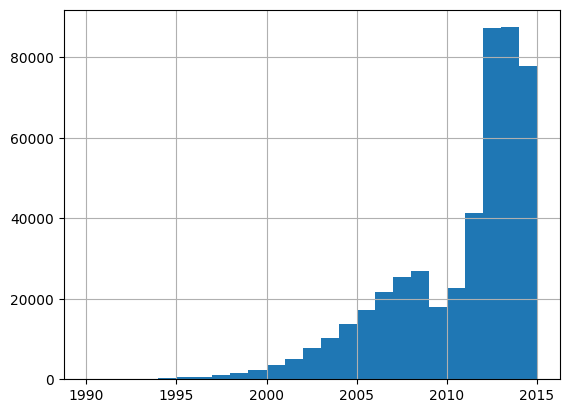

In [ ]:
df["year"].hist(bins=25)

In [ ]:
df["year"].describe()

,year
count,472357.000000
mean,2010.211258
std,3.822180
min,1990.000000
25%,2008.000000
50%,2012.000000
75%,2013.000000
max,2015.000000


In [ ]:
max_year = df["year"].max()
df.loc[:, "years_of_antiquity"] = df["year"].apply(lambda x: max_year - x)

<Axes: >

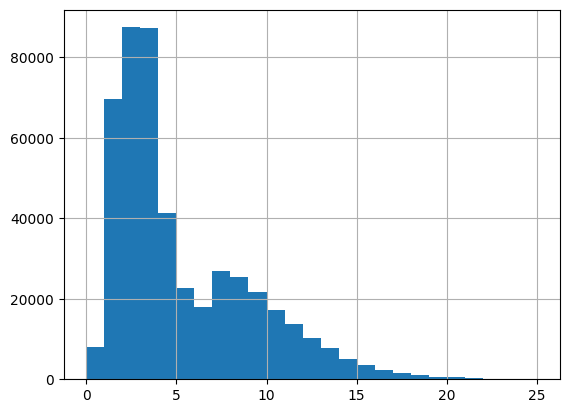

In [ ]:
df["years_of_antiquity"].hist(bins=25)

In [ ]:
print(f"Number of unique makers is {len(df['make'].unique())}")

Number of unique makers is 53


<Axes: xlabel='make'>

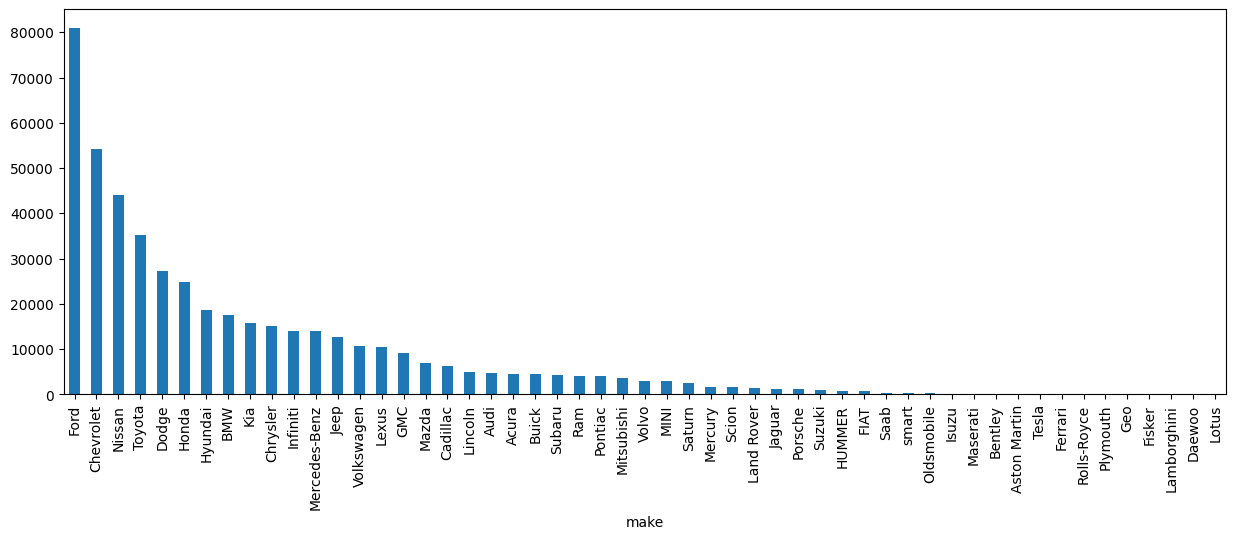

In [ ]:
df["make"].value_counts().plot(kind="bar", figsize=(15, 5))

In [ ]:
df["make"].value_counts(normalize=True)

,proportion
make,
Ford,0.171510
Chevrolet,0.114638
Nissan,0.093241
Toyota,0.074759
Dodge,0.057548
Honda,0.052462
Hyundai,0.039510
BMW,0.037067
Kia,0.033513


In [ ]:
print(f"Number of unique models is {len(df['model'].unique())}") # Tiene alta cardinalidad, no se usará

Number of unique models is 768


In [ ]:
print(f"Number of unique trims is {len(df['trim'].unique())}") # Tiene alta cardinalidad, no se usará

Number of unique trims is 1504


In [ ]:
print(f"Number of unique body types is {len(df['body'].unique())}")

Number of unique body types is 85


<Axes: xlabel='body'>

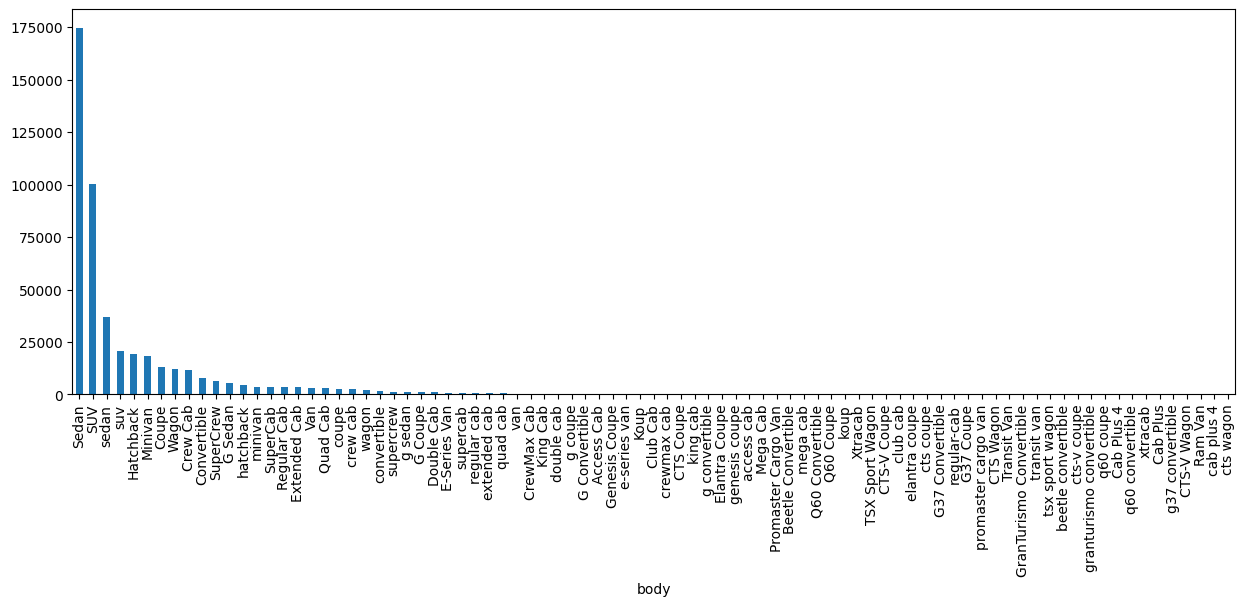

In [ ]:
df["body"].value_counts().plot(kind="bar", figsize=(15, 5))

In [ ]:
# 1. Forma I de agrupar, utilizando un diccionario explícito.
body_dict = {
    "Sedan": "Sedan",
    "SUV": "SUV",
    "Hatchback": "Hatchback",
    "G Sedan": "Sedan",
    "Convertible": "Convertible",
    "Wagon": "Wagon",
    "Minivan": "Minivan",
    "Crew Cab": "Cab",
    "G Coupe": "Coupe",
    "sedan": "Sedan"
}

pd.concat([df["body"].rename(index="body_raw"), df["body"].map(body_dict).rename(index="body_cleaned")], axis=1)

,body_raw,body_cleaned
0,SUV,SUV
1,SUV,SUV
2,Sedan,Sedan
3,Sedan,Sedan
4,Sedan,Sedan
...,...,...
558830,Sedan,Sedan
558832,Crew Cab,Cab
558833,SUV,SUV
558834,sedan,Sedan


In [ ]:
def body_cleaning_func(x):
  if "sedan" in x.lower():
    return "Sedan"
  elif "suv" in x.lower():
    return "SUV"
  elif "hatchback" in x.lower():
    return "Hatchback"
  elif "convertible" in x.lower():
    return "Convertible"
  elif "wagon" in x.lower():
    return "Wagon"
  elif "minivan" in x.lower():
    return "Minivan"
  elif "cab" in x.lower():
    return "Cab"
  elif "coupe" in x.lower() or "koup" in x.lower():
    return "Coupe"
  elif "van" in x.lower():
    return "Van"
  elif "supercrew" in x.lower():
    return "Super Crew"
  else:
    return x

df["body"] = df["body"].apply(body_cleaning_func)

<Axes: xlabel='body'>

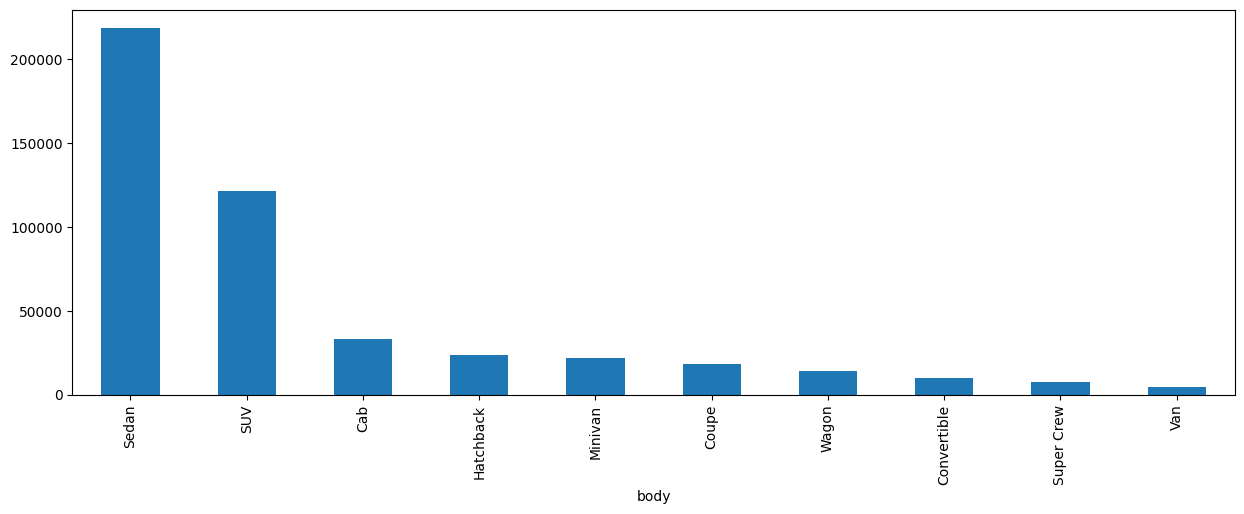

In [ ]:
df["body"].value_counts().plot(kind="bar", figsize=(15, 5))

In [ ]:
bodies_proportions = df["body"].value_counts(normalize=True)
bodies_proportions

,proportion
body,
Sedan,0.462083
SUV,0.256094
Cab,0.069723
Hatchback,0.050430
Minivan,0.046444
Coupe,0.038448
Wagon,0.030197
Convertible,0.020633
Super Crew,0.016009


In [ ]:
other_bodies_list = list(bodies_proportions[bodies_proportions < 0.04].index)
other_bodies_list

['Coupe', 'Wagon', 'Convertible', 'Super Crew', 'Van']

In [ ]:
df["body"] = df["body"].apply(lambda x: "Other" if x in other_bodies_list else x)

<Axes: xlabel='body'>

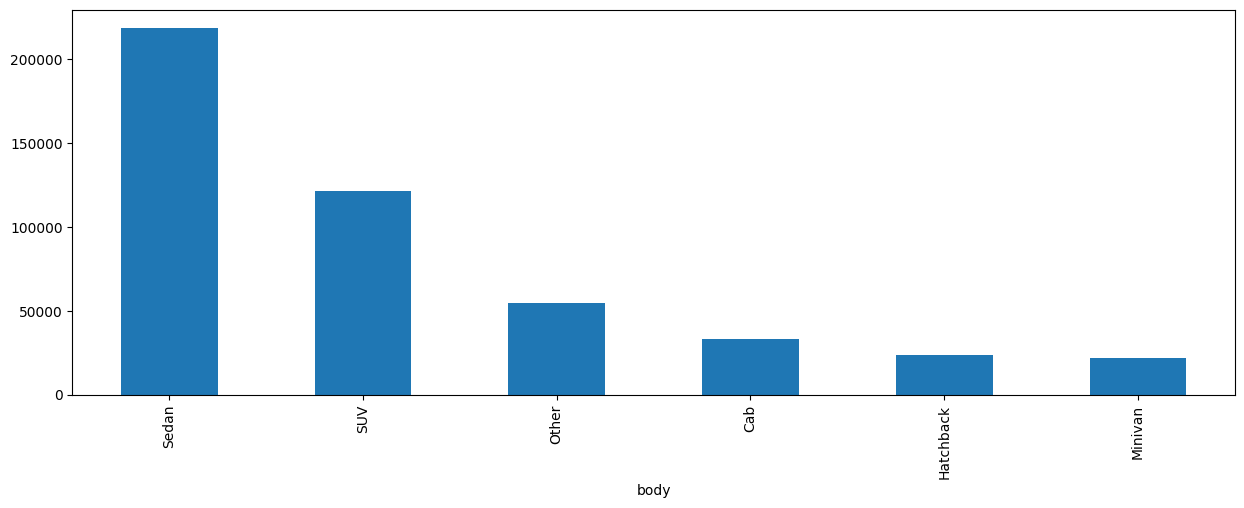

In [ ]:
df["body"].value_counts().plot(kind="bar", figsize=(15, 5))

In [ ]:
df["condition"] = df["condition"].astype("float64")
df["condition"].describe()

,condition
count,472357.000000
mean,3.426575
std,0.943684
min,1.000000
25%,2.700000
50%,3.600000
75%,4.200000
max,5.000000


<Axes: >

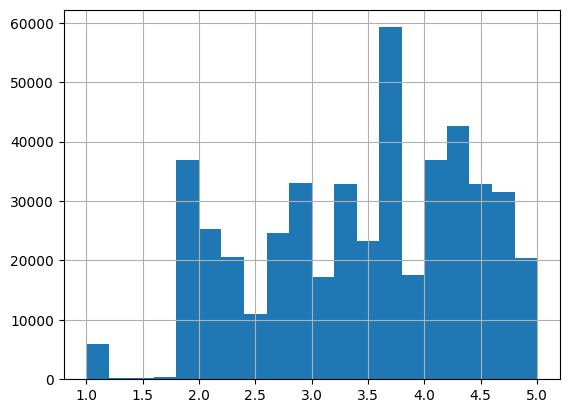

In [ ]:
df["condition"].hist(bins=20)

In [ ]:
df["price"] = df["sellingprice"].astype("float64")
df["price"].describe()

,price
count,472357.000000
mean,13690.334658
std,9612.765130
min,1.000000
25%,7200.000000
50%,12200.000000
75%,18200.000000
max,230000.000000


In [ ]:
df = df[[
    "years_of_antiquity",
    "body",
    "condition",
    "price"
]]

## EDA Post-FE

In [ ]:
df.select_dtypes(include="number").corr()

,years_of_antiquity,condition,price
years_of_antiquity,1.000000,-0.548259,-0.578888
condition,-0.548259,1.000000,0.535977
price,-0.578888,0.535977,1.000000


<Axes: xlabel='body', ylabel='price'>

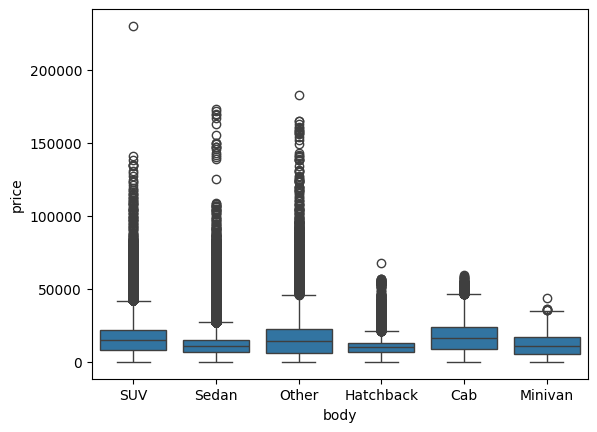

In [ ]:
sns.boxplot(data=df, x='body', y='price')

<Axes: xlabel='condition', ylabel='price'>

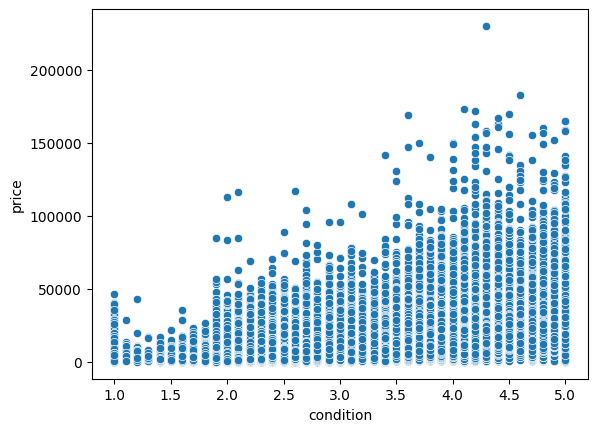

In [ ]:
sns.scatterplot(data=df, x='condition', y='price')

<Axes: xlabel='years_of_antiquity', ylabel='price'>

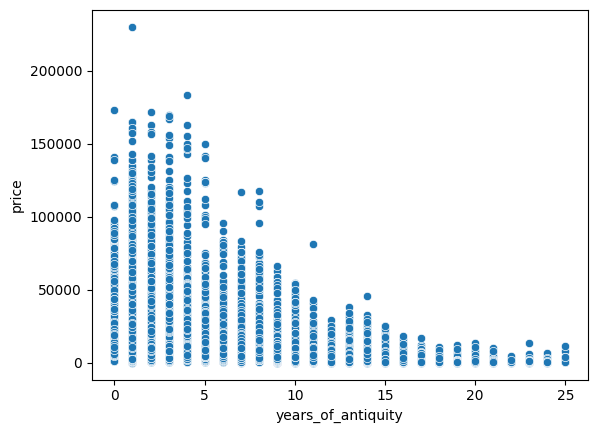

In [ ]:
sns.scatterplot(data=df, x='years_of_antiquity', y='price')

## Normalizing & Encoding

In [ ]:
# Encoding
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [ ]:
encoder = OneHotEncoder()
df_cat = df.select_dtypes(include="object")
encoder.fit(df_cat)
df_cat = pd.DataFrame(encoder.transform(df_cat).toarray(), columns=encoder.get_feature_names_out())
df_cat

,body_Cab,body_Hatchback,body_Minivan,body_Other,body_SUV,body_Sedan
0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...
472352,0.0,0.0,0.0,0.0,0.0,1.0
472353,1.0,0.0,0.0,0.0,0.0,0.0
472354,0.0,0.0,0.0,0.0,1.0,0.0
472355,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
# Normalizing
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
scaler = StandardScaler()
df_num = df.select_dtypes(include="number").drop("price", axis=1)
scaler.fit(df_num)
df_num = pd.DataFrame(scaler.transform(df_num), columns=df_num.columns)
df_num

,years_of_antiquity,condition
0,-1.252884,1.667324
1,-1.252884,1.667324
2,-0.991253,1.137485
3,-1.252884,0.713614
4,-0.991253,0.925550
...,...,...
472352,-0.206360,0.501678
472353,-0.467991,1.667324
472354,-0.467991,1.455389
472355,-1.252884,0.395711


## Splitting X and y

In [ ]:
X = pd.concat([df_num, df_cat], axis=1)
X

,years_of_antiquity,condition,body_Cab,body_Hatchback,body_Minivan,body_Other,body_SUV,body_Sedan
0,-1.252884,1.667324,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.252884,1.667324,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.991253,1.137485,0.0,0.0,0.0,0.0,0.0,1.0
3,-1.252884,0.713614,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.991253,0.925550,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
472352,-0.206360,0.501678,0.0,0.0,0.0,0.0,0.0,1.0
472353,-0.467991,1.667324,1.0,0.0,0.0,0.0,0.0,0.0
472354,-0.467991,1.455389,0.0,0.0,0.0,0.0,1.0,0.0
472355,-1.252884,0.395711,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
y = df["price"]
y

,price
0,21500.0
1,21500.0
2,30000.0
3,27750.0
4,67000.0
...,...
558830,22800.0
558832,30800.0
558833,34000.0
558834,11100.0


## Train models

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

model = RandomForestRegressor()

In [ ]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [ ]:
y_predicted = model.predict(X_test)

In [ ]:
df_results = pd.concat([y_test, pd.Series(y_predicted, index=y_test.index)], axis=1)
df_results.columns = ["real_price", "predicted_price"]
df_results

,real_price,predicted_price
212067,11400.0,9334.971313
460422,11600.0,14238.303033
13849,11900.0,12306.854841
492376,9400.0,15470.093573
148565,16500.0,14647.230222
...,...,...
330390,26100.0,19160.032868
471091,900.0,5984.099042
87404,20250.0,16345.558120
142491,13000.0,18475.644934


In [ ]:
print("MAE:", mean_absolute_error(y_test, y_predicted))
print("RSME:", root_mean_squared_error(y_test, y_predicted))
print("R2:", r2_score(y_test, y_predicted))

MAE: 4308.389016174705
RSME: 6777.5810854930405
R2: 0.51133971708927


<Axes: xlabel='real_price', ylabel='predicted_price'>

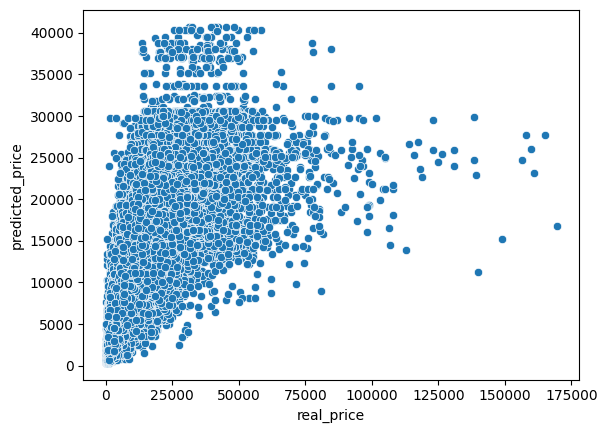

In [ ]:
sns.scatterplot(data=df_results, x="real_price", y="predicted_price")

In [ ]:
# Ejemplo de prueba rápida con varios modelos

models = [
    LinearRegression(),
    KNeighborsRegressor(),
    KNeighborsRegressor(n_neighbors=3),
    KNeighborsRegressor(n_neighbors=10),
    RandomForestRegressor(),
    RandomForestRegressor(n_estimators=50)
]

for model in models:
  model.fit(X_train, y_train)
  y_predicted = model.predict(X_test)
  print(model.__class__.__name__)
  print("MAE:", mean_absolute_error(y_test, y_predicted))
  print("RSME:", root_mean_squared_error(y_test, y_predicted))
  print("R2:", r2_score(y_test, y_predicted))
  print()

LinearRegression
MAE: 4693.392367657479
RSME: 7045.414963273324
R2: 0.4719552211992041

KNeighborsRegressor
MAE: 4793.093039207383
RSME: 7514.159981074598
R2: 0.3993541616473827

KNeighborsRegressor
MAE: 5095.246281085048
RSME: 8071.608903914288
R2: 0.3069288527963966

KNeighborsRegressor
MAE: 4618.4488811499705
RSME: 7189.8053291118185
R2: 0.45008969128537457

RandomForestRegressor
MAE: 4309.372389048265
RSME: 6777.9472393553715
R2: 0.5112869166341104

RandomForestRegressor
MAE: 4309.781805103657
RSME: 6778.910099814891
R2: 0.5111480557339152



In [ ]:
y_predicted = models[-1].predict(X_test)
df_results = pd.concat([y_test, pd.Series(y_predicted, index=y_test.index)], axis=1)
df_results.columns = ["real_price", "predicted_price"]
df_results = pd.concat([df.loc[df_results.index].drop("price", axis=1), df_results], axis=1)
df_results

,years_of_antiquity,body,condition,error,real_price,predicted_price
212067,6,Other,2.9,2004.970088,11400.0,9458.626897
460422,2,Minivan,3.5,3494.770111,11600.0,14199.952104
13849,6,Sedan,4.4,1275.747785,11900.0,12275.044092
492376,3,Sedan,4.0,6060.463998,9400.0,15430.345047
148565,4,Sedan,3.9,-2461.540534,16500.0,14582.380540
...,...,...,...,...,...,...
330390,1,Other,3.1,-6434.134701,26100.0,19098.412500
471091,10,Sedan,3.7,5738.602206,900.0,6009.998850
87404,2,Sedan,4.3,-2801.446503,20250.0,16350.119749
142491,4,SUV,3.8,4862.145872,13000.0,18494.913636


## Saving model

In [ ]:
import pickle
with open("model.pkl", "wb") as f:
  pickle.dump(models[-1], f)
with open("scaler.pkl", "wb") as f:
  pickle.dump(scaler, f)
with open("encoder.pkl", "wb") as f:
  pickle.dump(encoder, f)

## Loading model

In [ ]:
with open("model.pkl", "rb") as f:
  loaded_model = pickle.load(f)
with open("scaler.pkl", "rb") as f:
  loaded_scaler = pickle.load(f)
with open("encoder.pkl", "rb") as f:
  loaded_encoder = pickle.load(f)

In [ ]:
df_inference = df.drop("price", axis=1)
df_inference

,years_of_antiquity,body,condition
0,0,SUV,5.0
1,0,SUV,5.0
2,1,Sedan,4.5
3,0,Sedan,4.1
4,1,Sedan,4.3
...,...,...,...
558830,4,Sedan,3.9
558832,3,Cab,5.0
558833,3,SUV,4.8
558834,0,Sedan,3.8


In [ ]:
df_num_inference = df_inference.select_dtypes(include="number")
df_num_inference = pd.DataFrame(loaded_scaler.transform(df_num_inference), columns=df_num_inference.columns)
df_cat_inference = df_inference.select_dtypes(include="object")
df_cat_inference = pd.DataFrame(loaded_encoder.transform(df_cat_inference).toarray(), columns=loaded_encoder.get_feature_names_out())
X_inference = pd.concat([
    df_num_inference,
    df_cat_inference
], axis=1)
X_inference

,years_of_antiquity,condition,body_Cab,body_Hatchback,body_Minivan,body_Other,body_SUV,body_Sedan
0,-1.252884,1.667324,0.0,0.0,0.0,0.0,1.0,0.0
1,-1.252884,1.667324,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.991253,1.137485,0.0,0.0,0.0,0.0,0.0,1.0
3,-1.252884,0.713614,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.991253,0.925550,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...
472352,-0.206360,0.501678,0.0,0.0,0.0,0.0,0.0,1.0
472353,-0.467991,1.667324,1.0,0.0,0.0,0.0,0.0,0.0
472354,-0.467991,1.455389,0.0,0.0,0.0,0.0,1.0,0.0
472355,-1.252884,0.395711,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
y_predicted_inference = loaded_model.predict(X_inference)
df_results_inference = pd.concat([df_inference, pd.Series(y_predicted_inference, index=df_inference.index, name="model_prediction")], axis=1)
df_results_inference

,years_of_antiquity,body,condition,model_prediction
0,0,SUV,5.0,29942.094799
1,0,SUV,5.0,29942.094799
2,1,Sedan,4.5,18416.247815
3,0,Sedan,4.1,24047.249600
4,1,Sedan,4.3,17441.376678
...,...,...,...,...
558830,4,Sedan,3.9,14582.380540
558832,3,Cab,5.0,28928.504621
558833,3,SUV,4.8,21773.255788
558834,0,Sedan,3.8,16965.458565
